In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import seaborn as sns

In [4]:
df_DE_Canada = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] =='Canada')].copy()

df_DE_Canada = df_DE_Canada.dropna(subset=['salary_year_avg'])

In [5]:
# Step 1 - Explode first ✅
df_DE_Canada_exploded = df_DE_Canada.explode('job_skills')

# Step 2 - Drop NaN skills
df_DE_Canada_exploded = df_DE_Canada_exploded.dropna(subset=['job_skills'])

# Step 3 - Now groupby works ✅
df_DE_Canada_group = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DE_top_pay = df_DE_Canada_group.sort_values(by='median', ascending=False).head(10)

df_DE_skills = df_DE_Canada_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

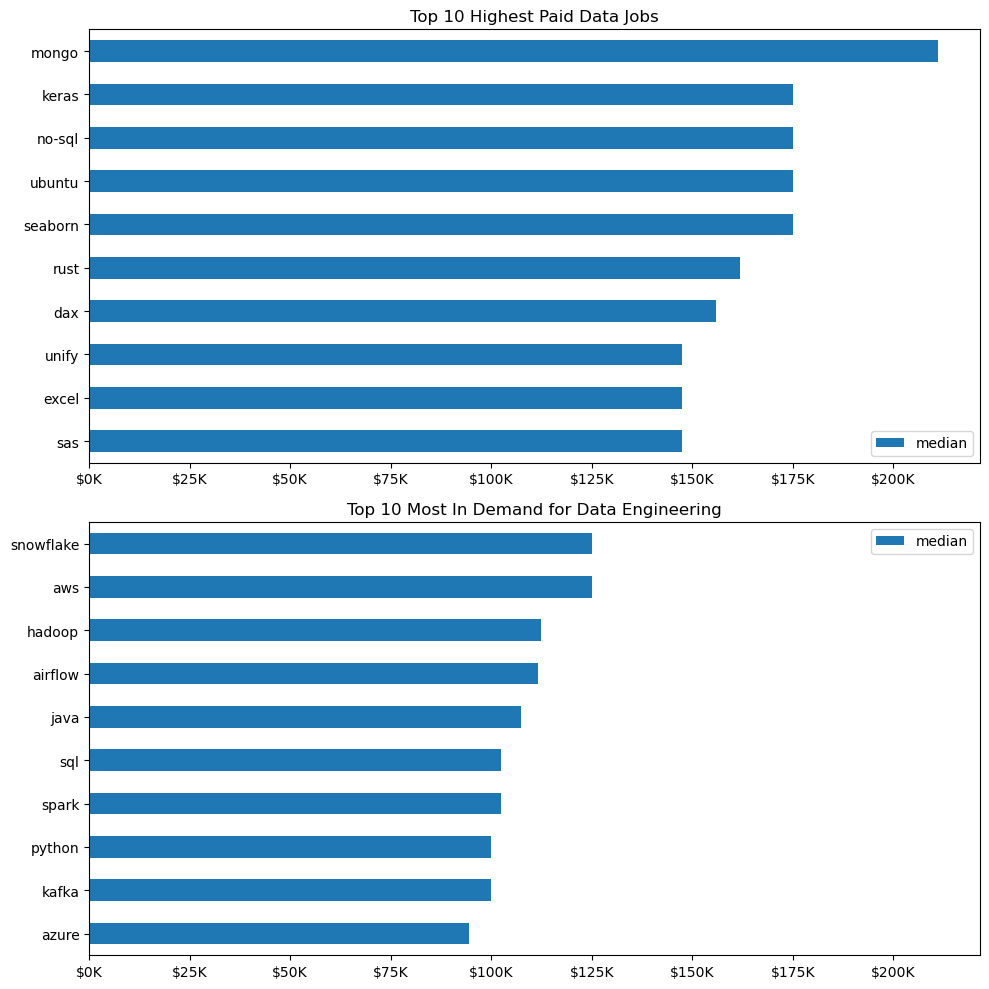

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

df_DE_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0])
ax[0].set_title('Top 10 Highest Paid Data Jobs')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

df_DE_skills[::-1].plot(kind='barh', y='median', ax=ax[1])
ax[1].set_title('Top 10 Most In Demand for Data Engineering')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

plt.tight_layout()
plt.show()

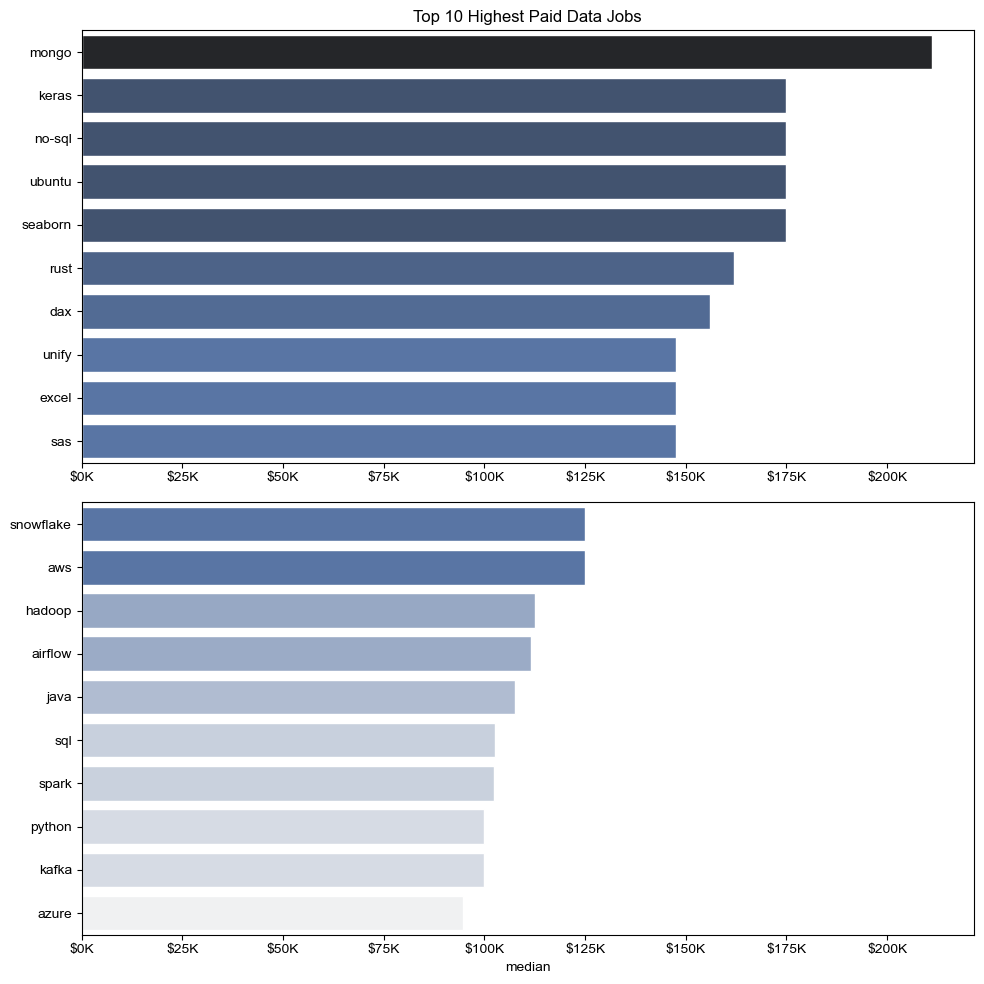

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

sns.set_theme(style="ticks")

# Top 10 Highest Paid skills in DE 
sns.barplot(data=df_DE_top_pay, x='median', y=df_DE_top_pay.index, ax=ax[0],hue='median',palette='dark:b_r')
ax[0].legend().remove()

ax[0].set_title('Top 10 Highest Paid Data Jobs')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

sns.barplot(data=df_DE_skills, x='median', y=df_DE_skills.index, ax=ax[1],hue='median',palette='light:b')
ax[1].legend().remove()

ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

plt.tight_layout()
plt.show()

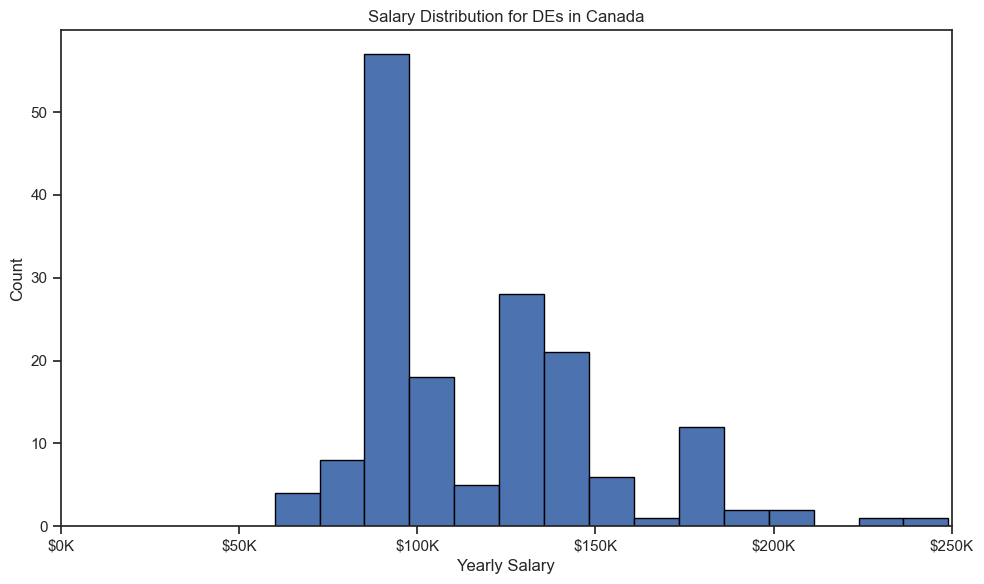

In [8]:
import matplotlib.ticker as mticker

df_DE_Canada['salary_year_avg'].plot(
    kind ='hist',
    bins=25,
    edgecolor ='black',
    figsize=(10, 6)
)
plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000):,}K'))


plt.xlabel('Yearly Salary')
plt.ylabel('Count')
plt.title('Salary Distribution for DEs in Canada')
plt.tight_layout()
plt.show()

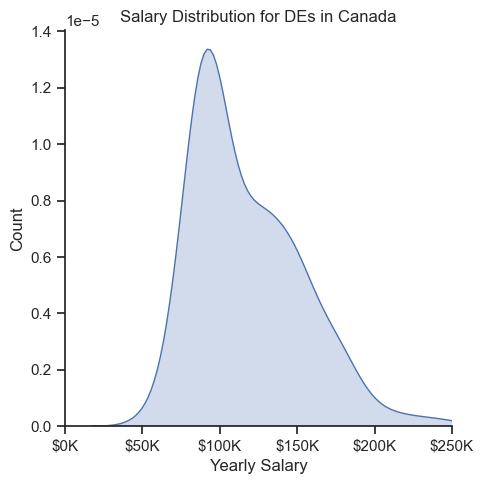

In [9]:

sns.displot(df_DE_Canada['salary_year_avg'], kind ='kde', fill=True)


plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000):,}K'))


plt.xlabel('Yearly Salary')
plt.ylabel('Count')
plt.title('Salary Distribution for DEs in Canada')
plt.tight_layout()
plt.show()

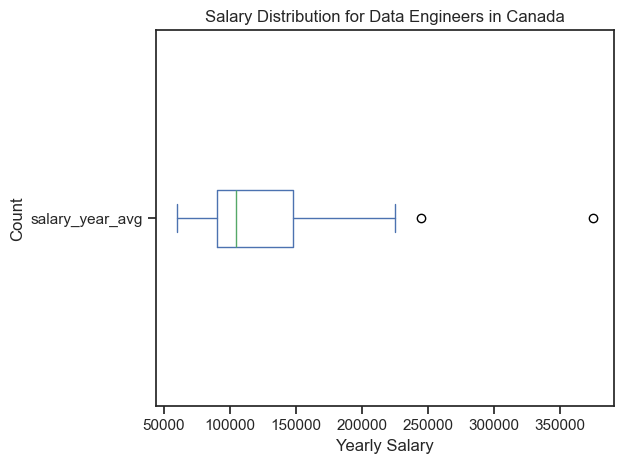

In [10]:
# Cell 2 - Now plot with correct column name ✅
df_DE_Canada['salary_year_avg'].plot(kind='box', vert=False)  # ✅ avg not uvg

plt.xlabel('Yearly Salary')
plt.ylabel('Count')
plt.title('Salary Distribution for Data Engineers in Canada')
plt.tight_layout()
plt.show()

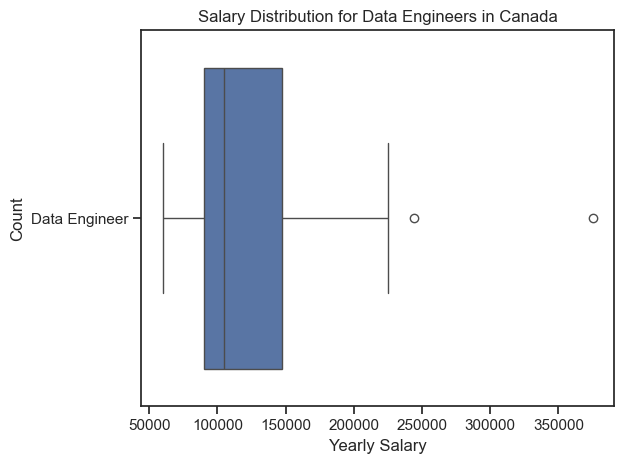

In [11]:
sns.boxplot(data=df_DE_Canada, x='salary_year_avg', y='job_title_short')

plt.xlabel('Yearly Salary')
plt.ylabel('Count')
plt.title('Salary Distribution for Data Engineers in Canada')
plt.tight_layout()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_12736\3384725617.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles, vert=False)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_12736\3384725617.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


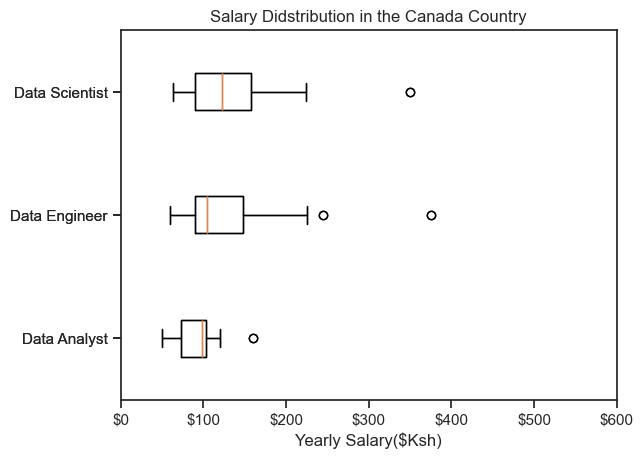

In [12]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_Canada = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] =='Canada')].copy()


df_Canada = df_Canada.dropna(subset=['salary_year_avg'])

job_list = [df_Canada[df_Canada['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list,labels=job_titles, vert=False)

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Didstribution in the Canada Country')
plt.xlabel('Yearly Salary($Ksh)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}'))
plt.xlim(0,600000)
plt.show()

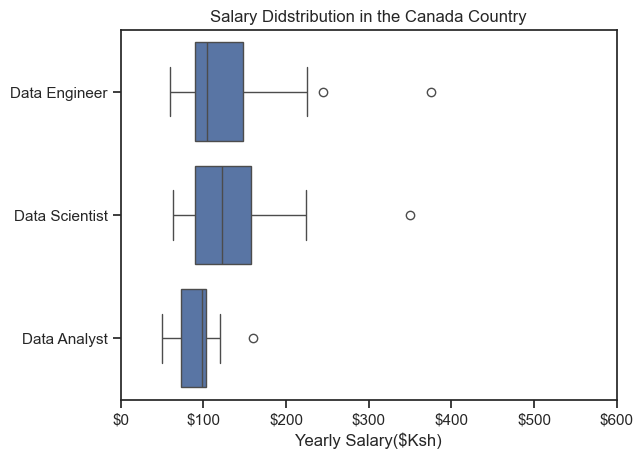

In [13]:
sns.boxplot(data=df_Canada, x='salary_year_avg',y='job_title_short')
sns.set_theme(style='ticks')



plt.title('Salary Didstribution in the Canada Country')
plt.xlabel('Yearly Salary($Ksh)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}'))
plt.xlim(0,600000)
plt.show()